# UK Accident Data Analysis


https://www.kaggle.com/code/devansodariya/uk-road-safety-accident-analysis/input


## 1. Environment Setup

## Resources

In [2]:
##pip install numpy


The data preprocessing pipeline involves several crucial steps to prepare the raw data for machine learning models. These steps are designed to clean the data, transform features into a suitable format, and address issues like class imbalance.

### 1. Data Cleaning and Initial Preparation

This first stage focuses on making the dataset consistent and removing irrelevant or problematic features.

- **Dropping Irrelevant Columns**: Columns like `Accident_Index`, `Location_Easting_OSGR`, `Location_Northing_OSGR`, `LSOA_of_Accident_Location`, `Latitude`, `Unnamed: 0`, `Junction_Control`, `Special_Conditions_at_Site`, and `Carriageway_Hazards` are dropped. These columns are either identifiers, geographical coordinates that might be too granular or collinear with other location features, or have a very high percentage of missing values, making them unsuitable for analysis.
- **Handling Missing Values**: After dropping the columns with excessive missing data, any remaining rows with missing values are dropped using `data.dropna(inplace=True)`. This ensures a complete dataset for model training.
- **Filtering Unmapped Categories**: An unmapped category (`Urban_or_Rural_Area = 3`) was identified and filtered out to ensure data consistency.
- **Separating Features and Target**: The dataset is split into features (`X`) and the target variable (`y`), where `Accident_Severity` is the target we aim to predict.

### 2. One-Hot Encoding for Categorical Features

Machine learning models typically require numerical input. One-Hot Encoding converts categorical variables into a numerical format.

- **Identifying Categorical Features**: Both `object` type columns and specific `int64` columns (`Day_of_Week`, `Police_Force`, `1st_Road_Class`, `2nd_Road_Class`, `Urban_or_Rural_Area`) are identified as categorical.
- **Applying `OneHotEncoder`**: A `ColumnTransformer` with `OneHotEncoder` is used to transform these identified categorical features. The `handle_unknown='ignore'` parameter ensures that new, unseen categories in the test set during deployment won't cause errors. Other numerical columns are passed through unchanged using `remainder='passthrough'`.

### 3. Train-Test Split

The dataset is divided into training and testing sets to evaluate the model's performance on unseen data.

- **Splitting Data**: `train_test_split` is used to create `X_train`, `X_test`, `y_train`, and `y_test`. A `test_size` of 0.2 means 20% of the data is reserved for testing.
- **Stratified Sampling**: `stratify=y` is crucial for this dataset due to the class imbalance in `Accident_Severity`. This ensures that the proportion of each `Accident_Severity` class is maintained in both the training and testing sets, providing a more representative evaluation.

### 4. Feature Scaling

Scaling features helps many machine learning algorithms converge faster and perform better.

- **`StandardScaler`**: A `StandardScaler` is initialized with `with_mean=False` because the input from one-hot encoding can be sparse. This scaler transforms features to have a mean of 0 and a standard deviation of 1.
- **Fitting and Transforming**: The scaler is `fit` *only* on the training data (`X_train`) to learn the scaling parameters and then used to `transform` both the training (`X_train`) and testing (`X_test`) sets. This prevents data leakage from the test set into the training process.

### 5. Handling Class Imbalance with SMOTENC

The `Accident_Severity` target variable is highly imbalanced, which can lead to models that perform poorly on minority classes. SMOTENC (Synthetic Minority Over-sampling Technique for Nominal and Continuous) addresses this by generating synthetic samples for minority classes.

- **Identifying Categorical Feature Indices**: The indices of the one-hot encoded categorical features are determined (`categorical_feature_indices_for_smotenc`) to inform SMOTENC which columns are categorical and should be handled appropriately during synthetic sample generation.
- **Target Variable Adjustment**: The target variable `y_train` is converted to be 0-indexed (`y_train_xgb_smote = y_train - 1`) as many machine learning libraries (like XGBoost) expect class labels to start from 0.
- **Applying SMOTENC**: `SMOTENC` is applied to the (unscaled, but encoded) training features (`X_train`) and the 0-indexed target (`y_train_xgb_smote`) to create `X_train_resampled` and `y_train_resampled_smote`. This balances the class distribution.
- **Scaling Resampled Data**: Finally, the newly generated synthetic samples and original training samples in `X_train_resampled` are scaled using the `scaler` that was previously fitted on the original `X_train`. This results in `X_train_resampled_scaled`, which is the fully preprocessed and balanced training dataset ready for model training.

### Install Required Libraries

In [51]:
!pip install xgboost imbalanced-learn

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   -----------------

In [4]:
import pip
!pip install pandas 
!pip install numpy 
!pip install matplotlib 
!pip install seaborn 
!pip install scikit-learn 
!pip install xgboost imbalanced-learn

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


## 2. Data Loading

You can replace `numpy` with the name of any other library you wish to install. If the library is already installed, `pip` will simply report that the requirement is already satisfied.

In [5]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Bundi\Documents\Data_Analytics\Datasets\UK\UK_Accident.csv", on_bad_lines='skip')
display(df.head())

,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


## 3.Summary Statistics

In [7]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1504150 entries, 0 to 1504149
Data columns (total 33 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Unnamed: 0                                   1504150 non-null  int64  
 1   Accident_Index                               1504150 non-null  str    
 2   Location_Easting_OSGR                        1504049 non-null  float64
 3   Location_Northing_OSGR                       1504150 non-null  float64
 4   Longitude                                    1504049 non-null  float64
 5   Latitude                                     1504150 non-null  float64
 6   Police_Force                                 1504150 non-null  int64  
 7   Accident_Severity                            1504150 non-null  int64  
 8   Number_of_Vehicles                           1504150 non-null  int64  
 9   Number_of_Casualties                         1504150 non-

None

In [8]:
display(df.describe())

,Unnamed: 0,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
count,1.504150e+06,1.504049e+06,1.504150e+06,1.504049e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06,1.504150e+06
mean,2.530433e+05,4.396214e+05,3.001382e+05,-1.436625e+00,5.258587e+01,3.020536e+01,2.838190e+00,1.831606e+00,1.350960e+00,4.118607e+00,3.476149e+02,4.087999e+00,1.009919e+03,3.900540e+01,2.675084e+00,3.815684e+02,1.353871e+00,2.009370e+03
std,1.489162e+05,9.511616e+04,1.610218e+05,1.398078e+00,1.512524e+00,2.551603e+01,4.018423e-01,7.147586e-01,8.253345e-01,1.924405e+00,2.594292e+02,1.428936e+00,1.823518e+03,1.413993e+01,3.205539e+00,1.302555e+03,4.783534e-01,3.013497e+00
min,0.000000e+00,6.495000e+04,0.000000e+00,-7.516225e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.000000e+00,1.000000e+01,-1.000000e+00,-1.000000e+00,1.000000e+00,2.005000e+03
25%,1.253452e+05,3.750600e+05,1.782600e+05,-2.373902e+00,5.149009e+01,6.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.100000e+02,3.000000e+00,0.000000e+00,3.000000e+01,-1.000000e+00,0.000000e+00,1.000000e+00,2.006000e+03
50%,2.506910e+05,4.399600e+05,2.688000e+05,-1.403714e+00,5.230888e+01,3.000000e+01,3.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,3.220000e+02,4.000000e+00,1.290000e+02,3.000000e+01,3.000000e+00,0.000000e+00,1.000000e+00,2.010000e+03
75%,3.760370e+05,5.230600e+05,3.981500e+05,-2.215100e-01,5.347855e+01,4.500000e+01,3.000000e+00,2.000000e+00,1.000000e+00,6.000000e+00,5.180000e+02,6.000000e+00,7.250000e+02,5.000000e+01,6.000000e+00,0.000000e+00,2.000000e+00,2.012000e+03
max,5.700100e+05,6.553700e+05,1.208800e+06,1.759398e+00,6.075754e+01,9.800000e+01,3.000000e+00,6.700000e+01,9.300000e+01,7.000000e+00,9.410000e+02,6.000000e+00,9.999000e+03,7.000000e+01,6.000000e+00,9.999000e+03,3.000000e+00,2.014000e+03


In [9]:
display(df.dtypes)

Unnamed: 0                                       int64
Accident_Index                                     str
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude                                      float64
Latitude                                       float64
Police_Force                                     int64
Accident_Severity                                int64
Number_of_Vehicles                               int64
Number_of_Casualties                             int64
Date                                               str
Day_of_Week                                      int64
Time                                               str
Local_Authority_(District)                       int64
Local_Authority_(Highway)                          str
1st_Road_Class                                   int64
1st_Road_Number                                  int64
Road_Type                                          str
Speed_limi

In [10]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

Location_Easting_OSGR                          101
Longitude                                      101
Time                                           117
Junction_Control                            602835
Pedestrian_Crossing-Human_Control               17
Pedestrian_Crossing-Physical_Facilities         34
Special_Conditions_at_Site                 1467568
Carriageway_Hazards                        1476900
LSOA_of_Accident_Location                   108238
dtype: int64

## Data Cleaning

**Handling Missing Values**

Columns with a very high number of missing values (e.g., over 90-95%) often do not provide enough information for meaningful analysis and can introduce noise. In this dataset, `Special_Conditions_at_Site` and `Carriageway_Hazards` have over 97% missing values. `Junction_Control` also has a significant portion of missing values (around 40%). For simplicity and to avoid issues with sparse data, we will drop these columns.

In [11]:
df.columns.tolist()

['Unnamed: 0',
 'Accident_Index',
 'Location_Easting_OSGR',
 'Location_Northing_OSGR',
 'Longitude',
 'Latitude',
 'Police_Force',
 'Accident_Severity',
 'Number_of_Vehicles',
 'Number_of_Casualties',
 'Date',
 'Day_of_Week',
 'Time',
 'Local_Authority_(District)',
 'Local_Authority_(Highway)',
 '1st_Road_Class',
 '1st_Road_Number',
 'Road_Type',
 'Speed_limit',
 'Junction_Control',
 '2nd_Road_Class',
 '2nd_Road_Number',
 'Pedestrian_Crossing-Human_Control',
 'Pedestrian_Crossing-Physical_Facilities',
 'Light_Conditions',
 'Weather_Conditions',
 'Road_Surface_Conditions',
 'Special_Conditions_at_Site',
 'Carriageway_Hazards',
 'Urban_or_Rural_Area',
 'Did_Police_Officer_Attend_Scene_of_Accident',
 'LSOA_of_Accident_Location',
 'Year']

In [12]:
columns_to_drop = ['Accident_Index',"Location_Easting_OSGR","Location_Northing_OSGR", 'LSOA_of_Accident_Location' ,'Latitude', 'Unnamed: 0',"Junction_Control","Special_Conditions_at_Site","Carriageway_Hazards"]
data = df.drop(columns=columns_to_drop)

print(f"Dropped columns: {columns_to_drop}")

Dropped columns: ['Accident_Index', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'LSOA_of_Accident_Location', 'Latitude', 'Unnamed: 0', 'Junction_Control', 'Special_Conditions_at_Site', 'Carriageway_Hazards']


Let's check the remaining missing values after dropping these columns.

In [13]:
data.head()

,Longitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),...,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
0,-0.191170,1,2,1,1,04/01/2005,3,17:42,12,E09000020,...,-1,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,1,Yes,2005
1,-0.211708,1,3,1,1,05/01/2005,4,17:36,12,E09000020,...,5,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,2005
2,-0.206458,1,3,2,1,06/01/2005,5,00:15,12,E09000020,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,2005
3,-0.173862,1,3,1,1,07/01/2005,6,10:35,12,E09000020,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1,Yes,2005
4,-0.156618,1,3,1,1,10/01/2005,2,21:13,12,E09000020,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,1,Yes,2005


In [14]:


missing_values_after_drop = data.isnull().sum()
display(missing_values_after_drop[missing_values_after_drop > 0])

Longitude                                  101
Time                                       117
Pedestrian_Crossing-Human_Control           17
Pedestrian_Crossing-Physical_Facilities     34
dtype: int64

Now, let's address the remaining missing values by dropping the rows that contain them. This is a common approach when the number of missing values is relatively small compared to the total dataset size, or if imputation is not suitable for the analysis.

In [15]:
print(f"Shape of DataFrame before dropping missing values: {data.shape}")
data.dropna(inplace=True)
print(f"Shape of DataFrame after dropping missing values: {data.shape}")

Shape of DataFrame before dropping missing values: (1504150, 24)
Shape of DataFrame after dropping missing values: (1503890, 24)


In [16]:

missing_values_after_drop = data.isnull().sum()
display(missing_values_after_drop[missing_values_after_drop > 0])

Series([], dtype: int64)

In [17]:
##missing_values_final = data.isnull().sum()
##display(missing_values_final[missing_values_final > 0])

In [18]:
display(data.describe())

,Longitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Day_of_Week,Local_Authority_(District),1st_Road_Class,1st_Road_Number,Speed_limit,2nd_Road_Class,2nd_Road_Number,Urban_or_Rural_Area,Year
count,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06,1.503890e+06
mean,-1.436520e+00,3.020021e+01,2.838194e+00,1.831621e+00,1.350979e+00,4.118607e+00,3.475674e+02,4.087969e+00,1.009915e+03,3.900459e+01,2.675217e+00,3.815975e+02,1.353757e+00,2.009370e+03
std,1.398061e+00,2.551040e+01,4.018412e-01,7.147609e-01,8.253654e-01,1.924414e+00,2.593859e+02,1.428924e+00,1.823443e+03,1.413953e+01,3.205509e+00,1.302591e+03,4.781838e-01,3.013390e+00
min,-7.516225e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-1.000000e+00,1.000000e+01,-1.000000e+00,-1.000000e+00,1.000000e+00,2.005000e+03
25%,-2.373724e+00,6.000000e+00,3.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,1.100000e+02,3.000000e+00,0.000000e+00,3.000000e+01,-1.000000e+00,0.000000e+00,1.000000e+00,2.006000e+03
50%,-1.403558e+00,3.000000e+01,3.000000e+00,2.000000e+00,1.000000e+00,4.000000e+00,3.220000e+02,4.000000e+00,1.290000e+02,3.000000e+01,3.000000e+00,0.000000e+00,1.000000e+00,2.010000e+03
75%,-2.214400e-01,4.500000e+01,3.000000e+00,2.000000e+00,1.000000e+00,6.000000e+00,5.180000e+02,6.000000e+00,7.250000e+02,5.000000e+01,6.000000e+00,0.000000e+00,2.000000e+00,2.012000e+03
max,1.759398e+00,9.800000e+01,3.000000e+00,6.700000e+01,9.300000e+01,7.000000e+00,9.410000e+02,6.000000e+00,9.999000e+03,7.000000e+01,6.000000e+00,9.999000e+03,3.000000e+00,2.014000e+03


## 4. Exploratory Data Analysis (EDA) - Visualizations

### 4.1 Univariate Analysis

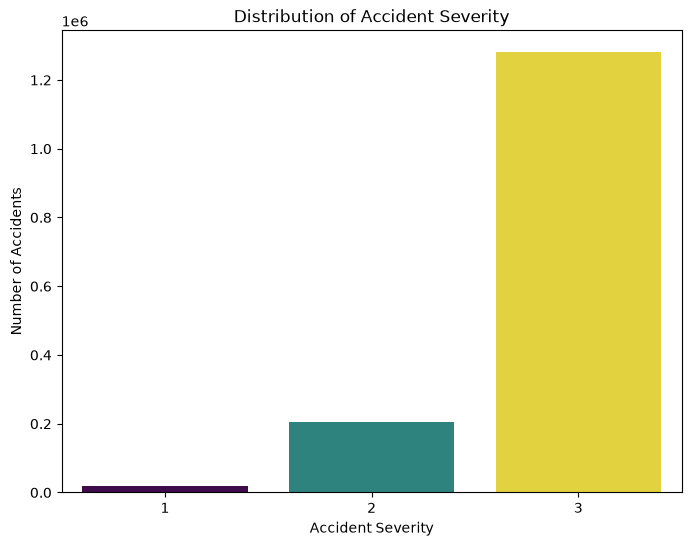

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Accident_Severity', data=data, palette='viridis', hue='Accident_Severity', legend=False)
plt.title('Distribution of Accident Severity')
plt.xlabel('Accident Severity')
plt.ylabel('Number of Accidents')
plt.show()



**Findings:**'Slight' accidents (severity 3) are by far the most common, followed by 'Serious' (severity 2), and then 'Fatal' accidents (severity 1), which are the least frequent.

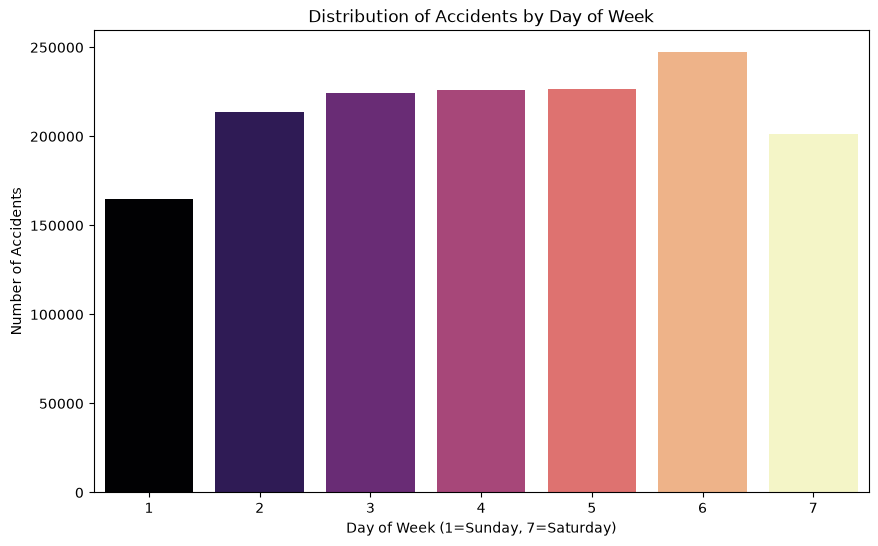

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Day_of_Week', data=data, palette='magma', hue='Day_of_Week', legend=False)
plt.title('Distribution of Accidents by Day of Week')
plt.xlabel('Day of Week (1=Sunday, 7=Saturday)')
plt.ylabel('Number of Accidents')
plt.show()

**Finding**


**Weekdays** (Monday to Friday, corresponding to 2-6 on the x-axis) generally have higher accident counts compared to weekends.

**Saturdays** (day 7) and Sundays (day 1) show notably lower accident frequencies than the weekdays.
Among the weekdays, Friday (day 6) appears to have the highest number of accidents, followed closely by Thursday (day 5), Wednesday (day 4), and Tuesday (day 3).

**Monday** (day 2) also has a high number of accidents, though slightly less than the other mid-week days.


In summary, there's a clear trend of higher accident counts during the working week, peaking towards the end of the week, and significantly lower counts over the weekend.

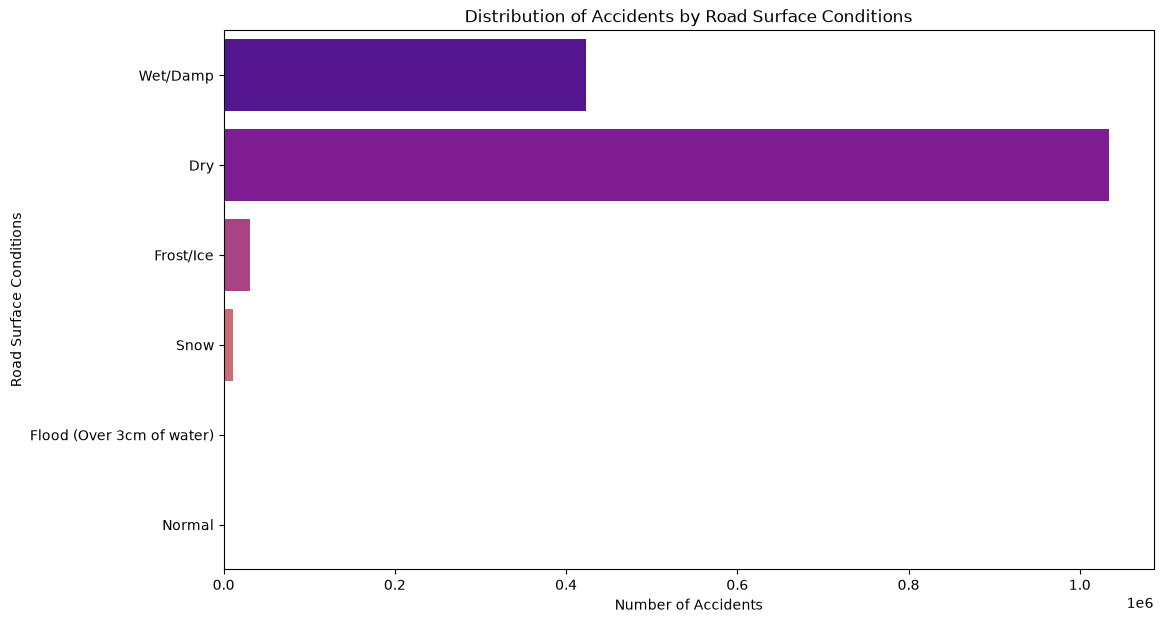

In [21]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Road_Surface_Conditions', data=data, palette='plasma', hue='Road_Surface_Conditions', legend=False)
plt.title('Distribution of Accidents by Road Surface Conditions')
plt.xlabel('Number of Accidents')
plt.ylabel('Road Surface Conditions')
plt.show()

**Findings**


Based on the analysis of road surface conditions and accident data, here's a summary of the findings:

**Dry conditions** are by far the most frequent road surface condition for accidents, accounting for the vast majority of incidents. However, the percentage of these accidents resulting in fatalities is relatively lower (around 1.29%) compared to some other severe conditions.


**Wet/Damp conditions** are the second most common cause of accidents, and they also exhibit a slightly higher percentage of fatal accidents (around 1.41%) than dry conditions.


**Frost/Ice and Snow** conditions cause a much smaller number of accidents. While these conditions make driving hazardous, their fatal accident percentages (around 1.05% for Frost/Ice and 0.70% for Snow) are generally lower than wet/damp or flooded conditions, possibly due to increased driver caution.


**Flood (Over 3cm of water)** is a very rare road surface
 condition for accidents, but when it does occur, it has the highest percentage of fatal accidents (approximately 1.89%), indicating extreme severity.


**Normal **conditions have a negligible number of accidents and the lowest fatal accident percentage (around 0.63%).


### 4.2 Bivariate Analysis

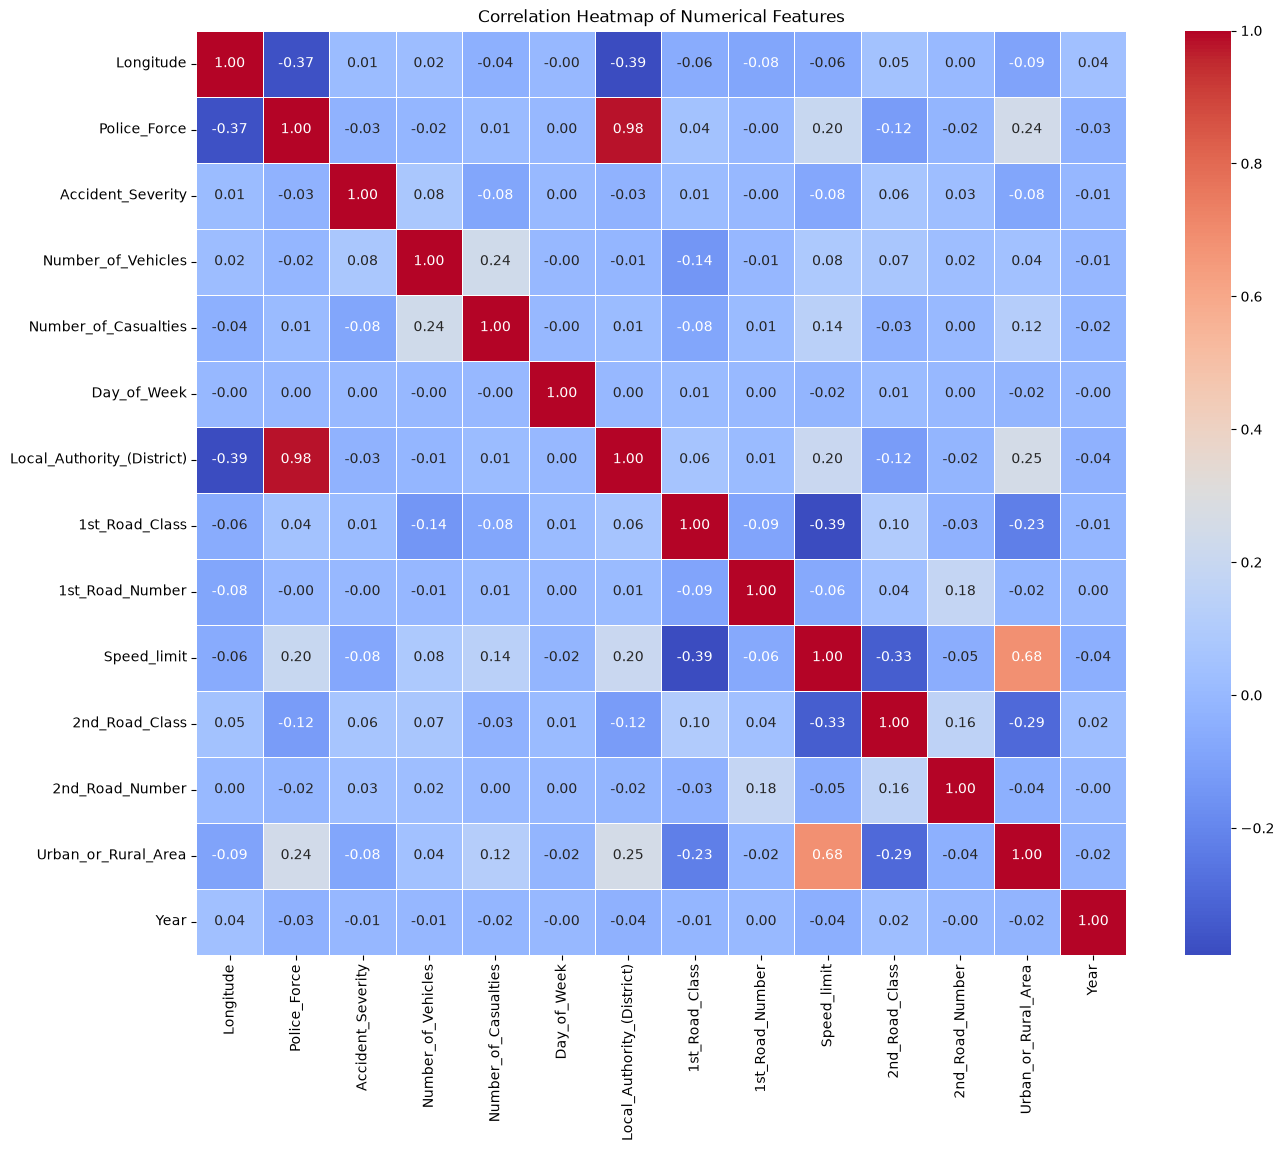

In [22]:
numerical_data = data.select_dtypes(include=['number'])
correlation_matrix = numerical_data.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Chart Explanation**


The correlation heatmap  visualizes the linear relationships between all numerical features in the dataset. Here's how to interpret it:

**Color Scale**: The coolwarm colormap ranges from dark blue (strong negative correlation) through white (no correlation) to dark red (strong positive correlation).



**Values**: The numbers in each cell indicate the Pearson correlation coefficient, ranging from -1 to 1.



**Positive values (red hues)**: Indicate that as one variable increases, the other tends to increase. For example, Number_of_Vehicles and Number_of_Casualties show a positive correlation (0.24), meaning more vehicles involved generally lead to more casualties.



**Negative values (blue hues)**: Indicate that as one variable increases, the other tends to decrease. For example, Accident_Severity and Number_of_Casualties show a small negative correlation (-0.08).



This is counter-intuitive if higher Accident_Severity values mean less severe accidents, which is often the case where 1=Fatal, 2=Serious, 3=Slight.


 If 3 is 'Slight', then a negative correlation with Number_of_Casualties means that as accidents become less severe (higher severity number), the number of casualties decreases, which makes sense.




**Values close to zero (white/light colors)**: Indicate a weak or no linear relationship between the variables.
Diagonal: The diagonal is always 1.00 because each variable is perfectly correlated with itself.



**Some Notable Observations from the Heatmap:**



**Number_of_Vehicles and Number_of_Casualties**: A moderate positive correlation (0.24), suggesting that more vehicles involved in an accident tend to lead to a higher number of casualties.
Speed_limit and Urban_or_Rural_Area: A strong negative correlation (-0.68). This makes sense, as rural areas (represented by '2' after filtering, assuming '1' is urban) generally have higher speed limits than urban areas (represented by '1').

**Accident_Severity**: Has generally weak correlations with other features, suggesting that predicting accident severity based solely on these numerical features might be challenging without considering categorical variables or more complex relationships.

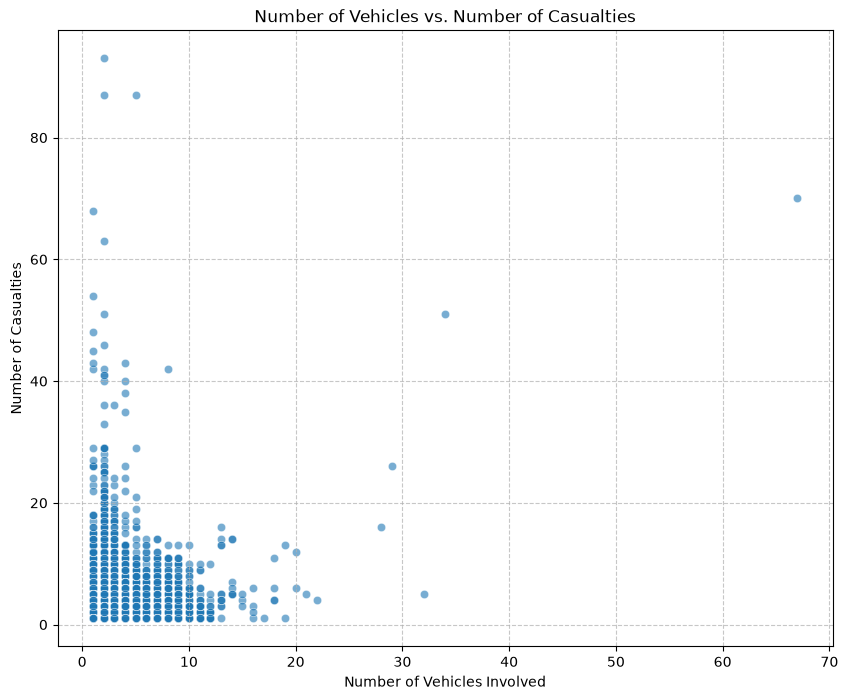

In [23]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Number_of_Vehicles', y='Number_of_Casualties', data=data, alpha=0.6)
plt.title('Number of Vehicles vs. Number of Casualties')
plt.xlabel('Number of Vehicles Involved')
plt.ylabel('Number of Casualties')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Correlation between 'Number_of_Casualties' and 'Speed_limit'

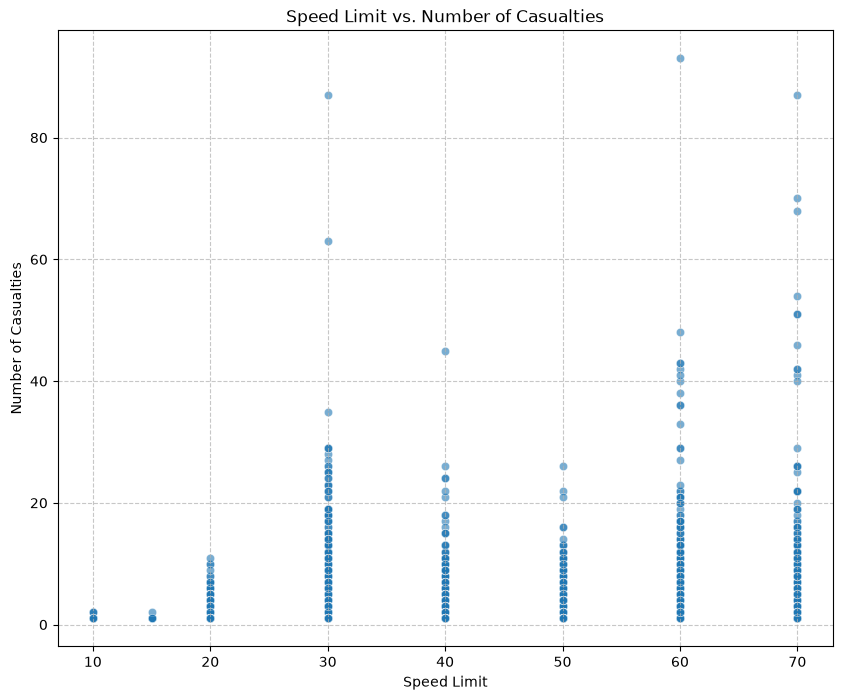

In [24]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Speed_limit', y='Number_of_Casualties', data=data, alpha=0.6)
plt.title('Speed Limit vs. Number of Casualties')
plt.xlabel('Speed Limit')
plt.ylabel('Number of Casualties')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Correlation Heatmap Focusing on Accident Severity Related Features

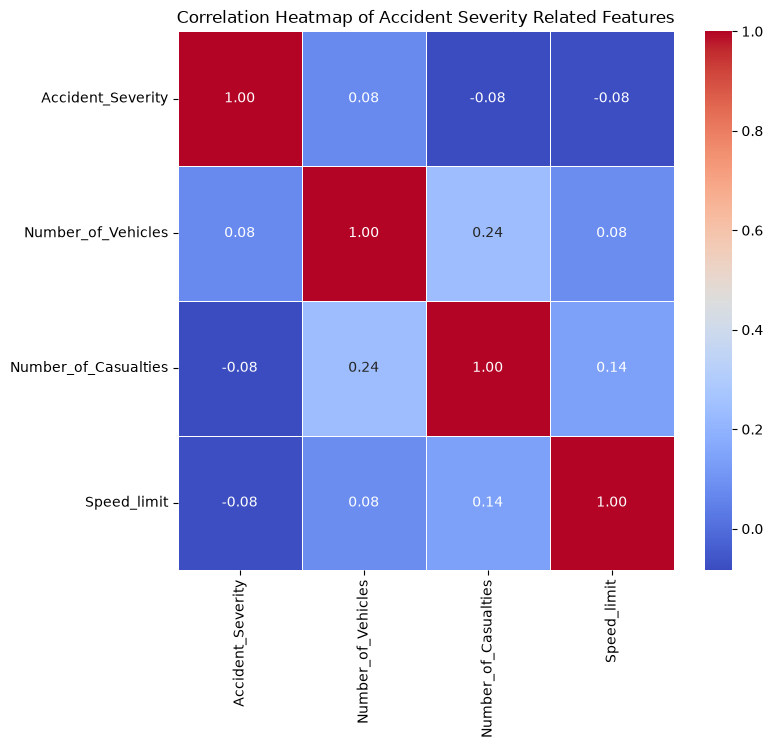

In [25]:
severity_related_features = ['Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit']
correlation_matrix_severity = data[severity_related_features].corr()

plt.figure(figsize=(8, 7))
sns.heatmap(correlation_matrix_severity, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Accident Severity Related Features')
plt.show()

In [26]:
cross_tab_severity_area = pd.crosstab(data['Urban_or_Rural_Area'], data['Accident_Severity'])
cross_tab_severity_area = cross_tab_severity_area.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
cross_tab_severity_area = cross_tab_severity_area.rename(index={1: 'Urban', 2: 'Rural'})
display(cross_tab_severity_area)

Accident_Severity,Fatal,Serious,Slight
Urban_or_Rural_Area,,,
Urban,6942,119619,845352
Rural,12497,84838,434607
3,0,3,32


Now, let's filter out the unmapped category '3' from the `Urban_or_Rural_Area` column and re-evaluate the cross-tabulation.

In [27]:
data = data[data['Urban_or_Rural_Area'] != 3]
print(f"Shape of DataFrame after filtering out Urban_or_Rural_Area = 3: {data.shape}")

Shape of DataFrame after filtering out Urban_or_Rural_Area = 3: (1503855, 24)


## 5. Machine Learning - Data Preparation

In [28]:
# Re-running data cleaning steps to ensure 'data' DataFrame is defined
# This combines steps from cells ddae5336, d94c4ff0, and 7e6f72fa

# Assuming 'df' (original loaded data) is already available from cell 3ae32ef
# If 'df' is not defined, please run cell 3ae32ef first.

columns_to_drop = ['Accident_Index', "Location_Easting_OSGR", "Location_Northing_OSGR", 'LSOA_of_Accident_Location', 'Latitude', 'Unnamed: 0', "Junction_Control", "Special_Conditions_at_Site", "Carriageway_Hazards"]
data = df.drop(columns=columns_to_drop)

# Drop rows with any remaining missing values
data.dropna(inplace=True)

# Filter out Urban_or_Rural_Area = 3, which was unmapped
data = data[data['Urban_or_Rural_Area'] != 3]

print("Data cleaning steps re-executed. 'data' DataFrame is now defined.")
print(f"Shape of 'data' after cleaning: {data.shape}")

Data cleaning steps re-executed. 'data' DataFrame is now defined.
Shape of 'data' after cleaning: (1503855, 24)


In [29]:
# Separating features (X) and target (y)
X = data.drop('Accident_Severity', axis=1)
y = data['Accident_Severity']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (1503855, 23)
Target (y) shape: (1503855,)


### One-Hot Encoding for Categorical Features
We will apply one-hot encoding to convert categorical columns into a format that can be provided to machine learning algorithms. We will identify `object` and `int64` columns that are truly categorical.


In [30]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical columns for one-hot encoding
# Exclude 'Accident_Severity' which is the target variable

categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# Assuming some 'int64' columns are also categorical, based on typical accident datasets.
# From previous EDA, 'Day_of_Week', 'Police_Force', '1st_Road_Class', '2nd_Road_Class', 'Urban_or_Rural_Area' are clear categorical features.
categorical_int_cols = ['Day_of_Week', 'Police_Force', '1st_Road_Class', '2nd_Road_Class', 'Urban_or_Rural_Area']

# Update categorical features list
categorical_features.extend(categorical_int_cols)

# Ensure no duplicates and all are in X.columns
categorical_features = [col for col in list(set(categorical_features)) if col in X.columns]

print(f"Identified categorical features: {categorical_features}")

# Create a column transformer for one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other numerical columns
)

# Apply preprocessing to X
X_encoded = preprocessor.fit_transform(X)

print(f"Shape of X after one-hot encoding: {X_encoded.shape}")

Identified categorical features: ['Light_Conditions', 'Urban_or_Rural_Area', 'Time', 'Date', 'Road_Type', 'Road_Surface_Conditions', 'Did_Police_Officer_Attend_Scene_of_Accident', '1st_Road_Class', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Local_Authority_(Highway)', 'Day_of_Week', 'Weather_Conditions', 'Police_Force', '2nd_Road_Class']


C:\Users\Bundi\AppData\Local\Temp\ipykernel_19756\2856618171.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


Shape of X after one-hot encoding: (1503855, 5050)


### Train-Test Split
We will split the data into training and testing sets to evaluate the model's performance on unseen data. We use `stratify=y` to maintain the proportion of `Accident_Severity` classes in both training and testing sets, which is crucial for imbalanced datasets.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of Accident Severity in y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution of Accident Severity in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (1203084, 5050)
X_test shape: (300771, 5050)
y_train shape: (1203084,)
y_test shape: (300771,)

Distribution of Accident Severity in y_train:
Accident_Severity
3    0.851118
2    0.135956
1    0.012926
Name: proportion, dtype: float64

Distribution of Accident Severity in y_test:
Accident_Severity
3    0.851119
2    0.135954
1    0.012927
Name: proportion, dtype: float64


### Feature Scaling
We will scale the numerical features using `StandardScaler`. This is important for many machine learning algorithms, especially those sensitive to the magnitude of feature values (like Logistic Regression and algorithms using gradient descent). It's crucial to fit the scaler only on the training data and then transform both training and testing data to prevent data leakage.

In [32]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler(with_mean=False) # with_mean=False is used if input is sparse matrix

# Fit the scaler on the training features and transform both training and test features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

# Define categorical feature indices for SMOTE-NC
# Get the one-hot encoded feature names to determine indices
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

categorical_feature_indices_for_smotenc = list(range(len(ohe_feature_names)))
print(f"Categorical feature indices for SMOTE-NC: {categorical_feature_indices_for_smotenc[0]} to {categorical_feature_indices_for_smotenc[-1]}")


Features scaled successfully!
X_train_scaled shape: (1203084, 5050)
X_test_scaled shape: (300771, 5050)
Categorical feature indices for SMOTE-NC: 0 to 5041


In [33]:
cross_tab_severity_area = pd.crosstab(data['Urban_or_Rural_Area'], data['Accident_Severity'])
cross_tab_severity_area = cross_tab_severity_area.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
cross_tab_severity_area = cross_tab_severity_area.rename(index={1: 'Urban', 2: 'Rural'})
display(cross_tab_severity_area)

Accident_Severity,Fatal,Serious,Slight
Urban_or_Rural_Area,,,
Urban,6942,119619,845352
Rural,12497,84838,434607


#### Accident Severity Counts: Urban vs. Rural Areas

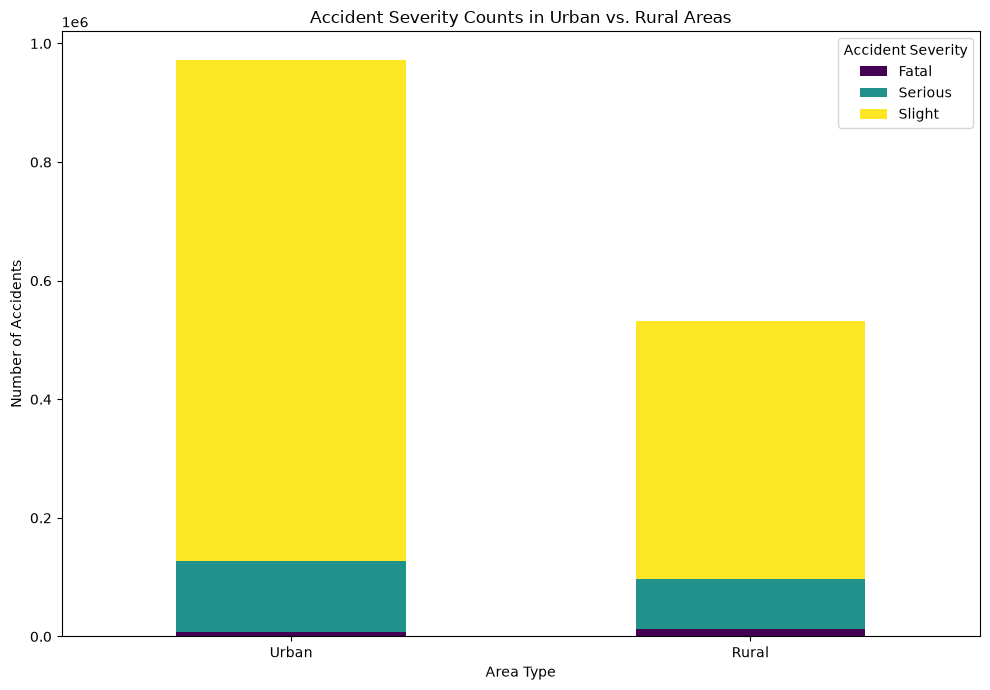

In [34]:
cross_tab_severity_area.plot(kind='bar', stacked=True, figsize=(10, 7), colormap='viridis')
plt.title('Accident Severity Counts in Urban vs. Rural Areas')
plt.xlabel('Area Type')
plt.ylabel('Number of Accidents')
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.legend(title='Accident Severity')
plt.tight_layout()
plt.show()

#### Percentage of Fatal Accidents in Urban vs. Rural Areas

In [35]:
total_accidents_urban = cross_tab_severity_area.loc['Urban'].sum()
total_accidents_rural = cross_tab_severity_area.loc['Rural'].sum()

fatal_accidents_urban = cross_tab_severity_area.loc['Urban', 'Fatal']
fatal_accidents_rural = cross_tab_severity_area.loc['Rural', 'Fatal']

percentage_fatal_urban = (fatal_accidents_urban / total_accidents_urban) * 100
percentage_fatal_rural = (fatal_accidents_rural / total_accidents_rural) * 100

print(f"Percentage of Fatal Accidents in Urban Areas: {percentage_fatal_urban:.2f}%")
print(f"Percentage of Fatal Accidents in Rural Areas: {percentage_fatal_rural:.2f}%")

Percentage of Fatal Accidents in Urban Areas: 0.71%
Percentage of Fatal Accidents in Rural Areas: 2.35%


#### Visualization of Fatal Accident Percentages: Urban vs. Rural

C:\Users\Bundi\AppData\Local\Temp\ipykernel_19756\4288697266.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=areas, y=values, palette='coolwarm')


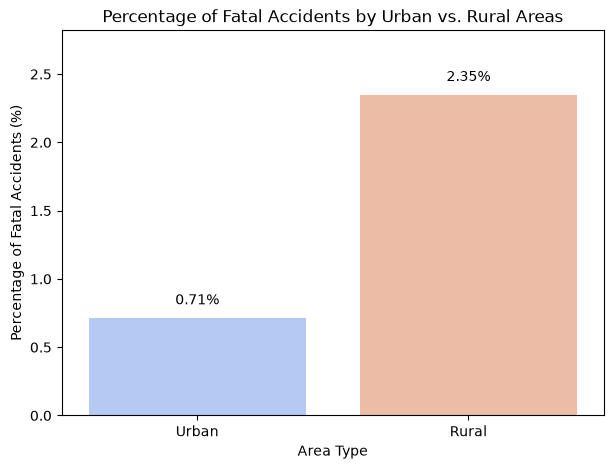

In [36]:
percentages = {'Urban': percentage_fatal_urban, 'Rural': percentage_fatal_rural}
areas = list(percentages.keys())
values = list(percentages.values())

plt.figure(figsize=(7, 5))
sns.barplot(x=areas, y=values, palette='coolwarm')
plt.title('Percentage of Fatal Accidents by Urban vs. Rural Areas')
plt.xlabel('Area Type')
plt.ylabel('Percentage of Fatal Accidents (%)')
plt.ylim(0, max(values) * 1.2) # Set y-axis limit slightly above max value

for index, value in enumerate(values):
    plt.text(index, value + 0.1, f'{value:.2f}%', color='black', ha="center")

plt.show()

### Fatality Percentage by Weather Conditions

In [37]:
cross_tab_weather_severity = pd.crosstab(data['Weather_Conditions'], data['Accident_Severity'])
cross_tab_weather_severity = cross_tab_weather_severity.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
display(cross_tab_weather_severity)

# Calculate total accidents and fatal accidents for each weather condition
total_accidents_by_weather = cross_tab_weather_severity.sum(axis=1)
fatal_accidents_by_weather = cross_tab_weather_severity['Fatal']

# Calculate percentage of fatal accidents for each weather condition
percentage_fatal_by_weather = (fatal_accidents_by_weather / total_accidents_by_weather) * 100

print("\nPercentage of Fatal Accidents by Weather Condition:")
display(percentage_fatal_by_weather.sort_values(ascending=False))

Accident_Severity,Fatal,Serious,Slight
Weather_Conditions,,,
Fine with high winds,339,2688,15325
Fine without high winds,16143,168742,1018837
Fog or mist,179,1147,6861
Other,294,3677,29524
Raining with high winds,280,2769,17760
Raining without high winds,1854,21438,154337
Snowing with high winds,13,224,1722
Snowing without high winds,90,1078,10132
Unknown,247,2694,25461



Percentage of Fatal Accidents by Weather Condition:


Weather_Conditions
Fog or mist                   2.186393
Fine with high winds          1.847210
Raining with high winds       1.345572
Fine without high winds       1.341090
Raining without high winds    1.043748
Other                         0.877743
Unknown                       0.869657
Snowing without high winds    0.796460
Snowing with high winds       0.663604
dtype: float64

C:\Users\Bundi\AppData\Local\Temp\ipykernel_19756\3870845750.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentage_fatal_by_weather.index, y=percentage_fatal_by_weather.values, palette='viridis')


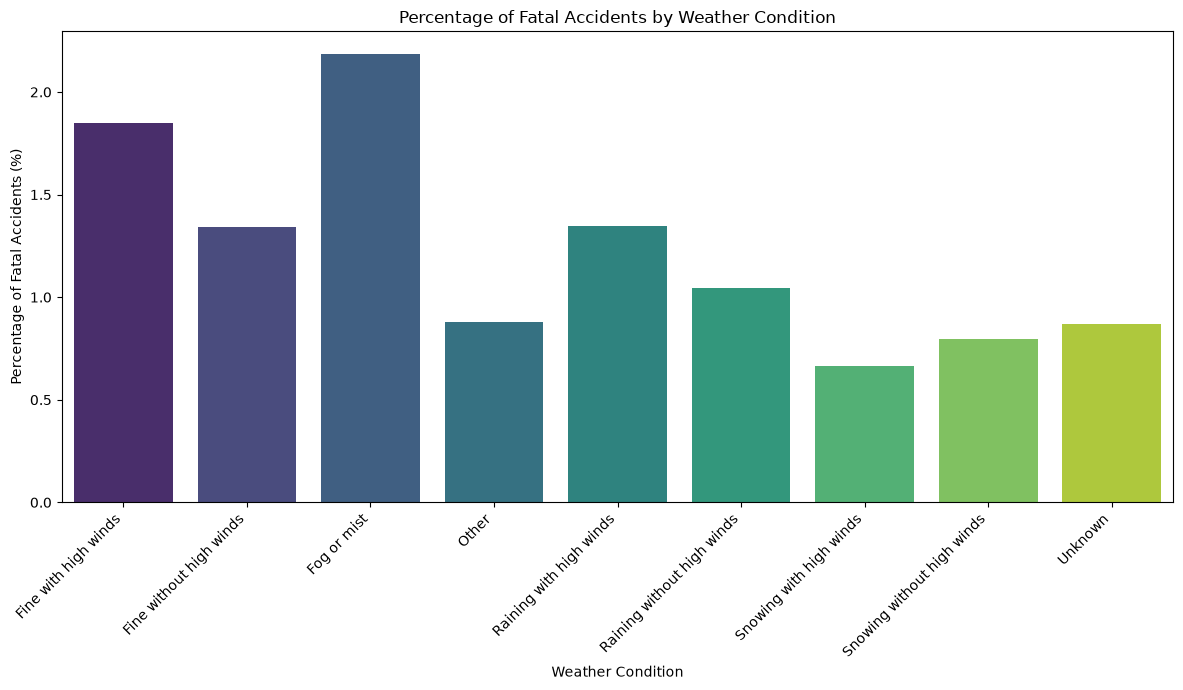

In [38]:
plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_fatal_by_weather.index, y=percentage_fatal_by_weather.values, palette='viridis')
plt.title('Percentage of Fatal Accidents by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Percentage of Fatal Accidents (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4.3 Multivariate Analysis

#### Filtering for High-Casualty Accidents

To focus on accidents with a significant impact, we will filter the dataset to include only those classified as 'high-casualty'. We will define 'high-casualty' as accidents resulting in more than 5 casualties. This threshold can be adjusted as needed.

In [39]:
# Define the threshold for high-casualty accidents
high_casualty_threshold = 5

# Filter the data (using the already filtered 'data' DataFrame)
high_casualty_data = data[data['Number_of_Casualties'] > high_casualty_threshold]

print(f"Original dataset shape: {data.shape}")
print(f"High-casualty dataset shape (>{high_casualty_threshold} casualties): {high_casualty_data.shape}")

display(high_casualty_data.head())

Original dataset shape: (1503855, 24)
High-casualty dataset shape (>5 casualties): (5885, 24)


,Longitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Local_Authority_(District),Local_Authority_(Highway),...,2nd_Road_Class,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,Year
427,-0.215626,1,3,1,8,17/08/2005,4,18:25,12,E09000020,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1,Yes,2005
5574,-0.058933,1,2,2,7,04/02/2005,6,21:35,5,E09000030,...,5,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,2005
6847,-0.016488,1,2,2,6,13/08/2005,7,21:38,13,E09000031,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Raining without high winds,Wet/Damp,1,Yes,2005
7577,0.085227,1,2,3,7,15/08/2005,2,12:35,14,E09000026,...,6,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1,Yes,2005
8216,0.282102,1,3,8,7,07/06/2005,3,06:26,15,E09000016,...,-1,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,2,Yes,2005


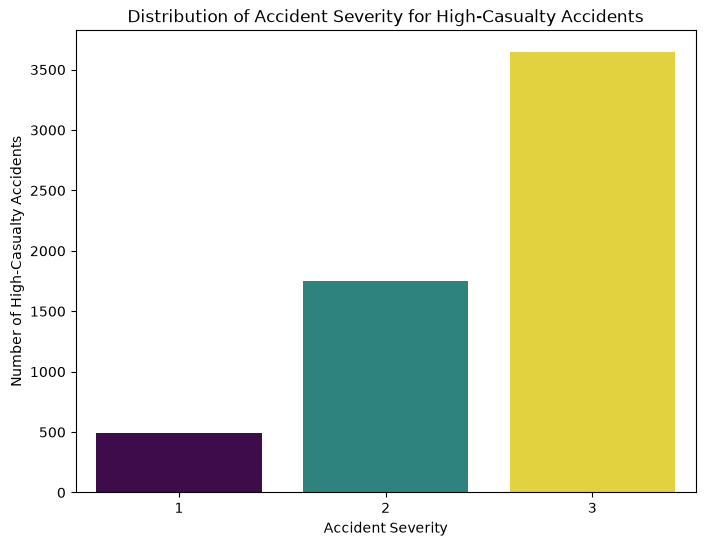

In [40]:
plt.figure(figsize=(8, 6))
sns.countplot(x='Accident_Severity', data=high_casualty_data, palette='viridis', hue='Accident_Severity', legend=False)
plt.title('Distribution of Accident Severity for High-Casualty Accidents')
plt.xlabel('Accident Severity')
plt.ylabel('Number of High-Casualty Accidents')
plt.show()

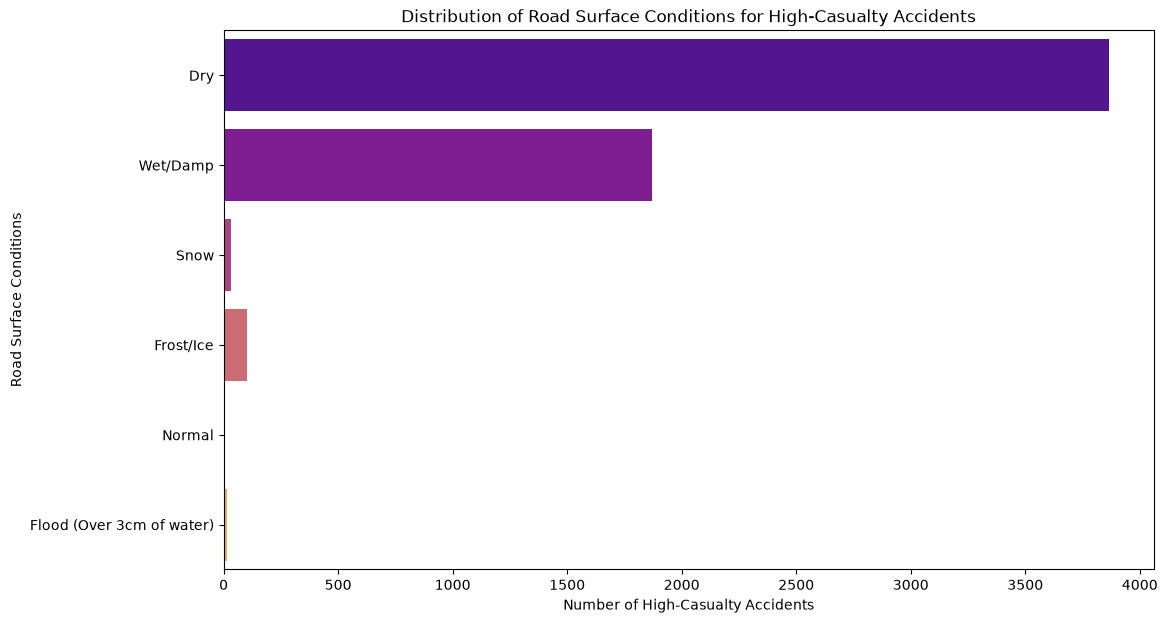

In [41]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Road_Surface_Conditions', data=high_casualty_data, palette='plasma', hue='Road_Surface_Conditions', legend=False)
plt.title('Distribution of Road Surface Conditions for High-Casualty Accidents')
plt.xlabel('Number of High-Casualty Accidents')
plt.ylabel('Road Surface Conditions')
plt.show()

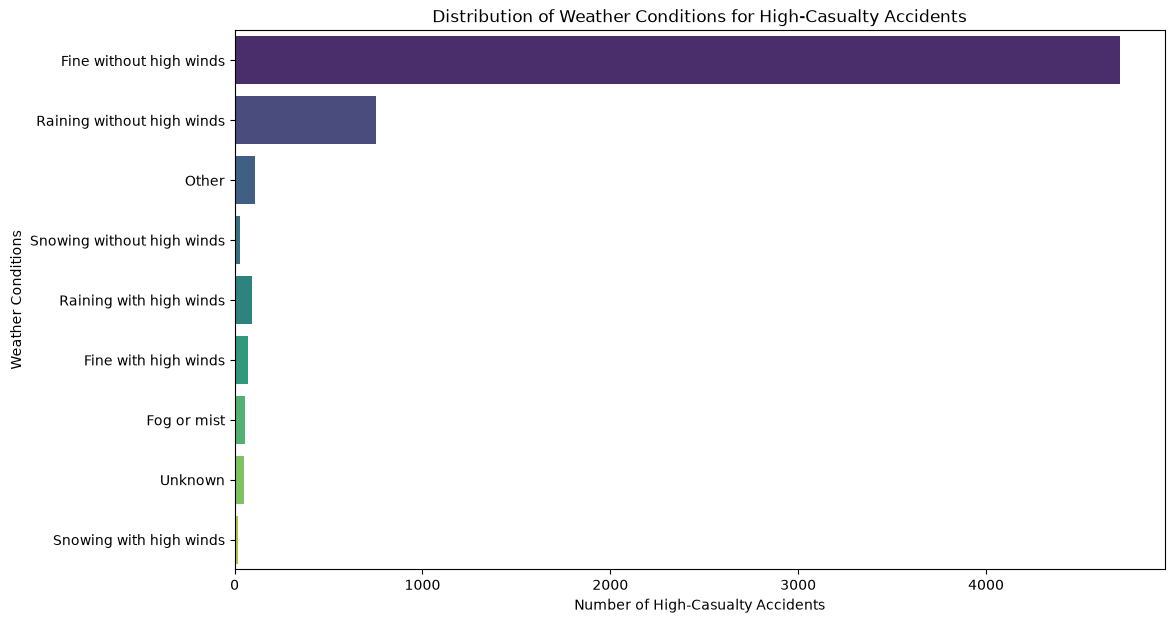

In [42]:
plt.figure(figsize=(12, 7))
sns.countplot(y='Weather_Conditions', data=high_casualty_data, palette='viridis', hue='Weather_Conditions', legend=False)
plt.title('Distribution of Weather Conditions for High-Casualty Accidents')
plt.xlabel('Number of High-Casualty Accidents')
plt.ylabel('Weather Conditions')
plt.show()

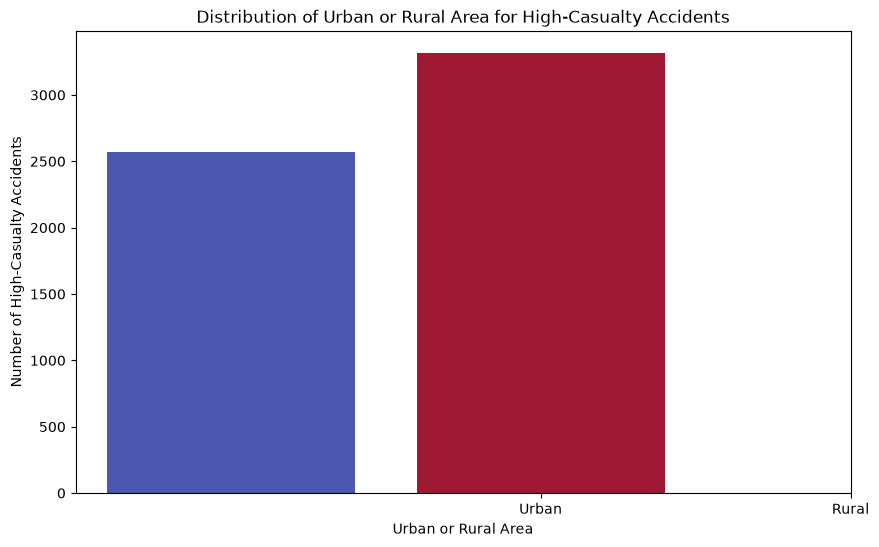

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Urban_or_Rural_Area', data=high_casualty_data, palette='coolwarm', hue='Urban_or_Rural_Area', legend=False)
plt.title('Distribution of Urban or Rural Area for High-Casualty Accidents')
plt.xlabel('Urban or Rural Area')
plt.ylabel('Number of High-Casualty Accidents')
plt.xticks(ticks=[1, 2], labels=['Urban', 'Rural']) # Explicitly setting labels for 1 and 2
plt.show()

In [44]:
mean_casualties_urban_rural = high_casualty_data.groupby('Urban_or_Rural_Area')['Number_of_Casualties'].mean().reset_index()
print("Mean Number of Casualties for High-Casualty Accidents by Urban/Rural Area:")
mean_casualties_urban_rural['Urban_or_Rural_Area'] = mean_casualties_urban_rural['Urban_or_Rural_Area'].map({1: 'Urban', 2: 'Rural'})
display(mean_casualties_urban_rural)

Mean Number of Casualties for High-Casualty Accidents by Urban/Rural Area:


,Urban_or_Rural_Area,Number_of_Casualties
0,Urban,7.042818
1,Rural,7.443607


### Fatality Percentage by Road Surface Conditions

In [45]:
cross_tab_road_severity = pd.crosstab(data['Road_Surface_Conditions'], data['Accident_Severity'])
cross_tab_road_severity = cross_tab_road_severity.rename(columns={1: 'Fatal', 2: 'Serious', 3: 'Slight'})
display(cross_tab_road_severity)

# Calculate total accidents and fatal accidents for each road surface condition
total_accidents_by_road = cross_tab_road_severity.sum(axis=1)
fatal_accidents_by_road = cross_tab_road_severity['Fatal']

# Calculate percentage of fatal accidents for each road surface condition
percentage_fatal_by_road = (fatal_accidents_by_road / total_accidents_by_road) * 100

print("\nPercentage of Fatal Accidents by Road Surface Condition:")
display(percentage_fatal_by_road.sort_values(ascending=False))

Accident_Severity,Fatal,Serious,Slight
Road_Surface_Conditions,,,
Dry,13032,143672,877773
Flood (Over 3cm of water),41,288,1813
Frost/Ice,326,3615,27458
Normal,12,200,1737
Snow,74,1033,9389
Wet/Damp,5954,55649,361789



Percentage of Fatal Accidents by Road Surface Condition:


Road_Surface_Conditions
Flood (Over 3cm of water)    1.914099
Wet/Damp                     1.406262
Dry                          1.259767
Frost/Ice                    1.038250
Snow                         0.705030
Normal                       0.615700
dtype: float64

C:\Users\Bundi\AppData\Local\Temp\ipykernel_19756\3118003756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=percentage_fatal_by_road.index, y=percentage_fatal_by_road.values, palette='viridis')


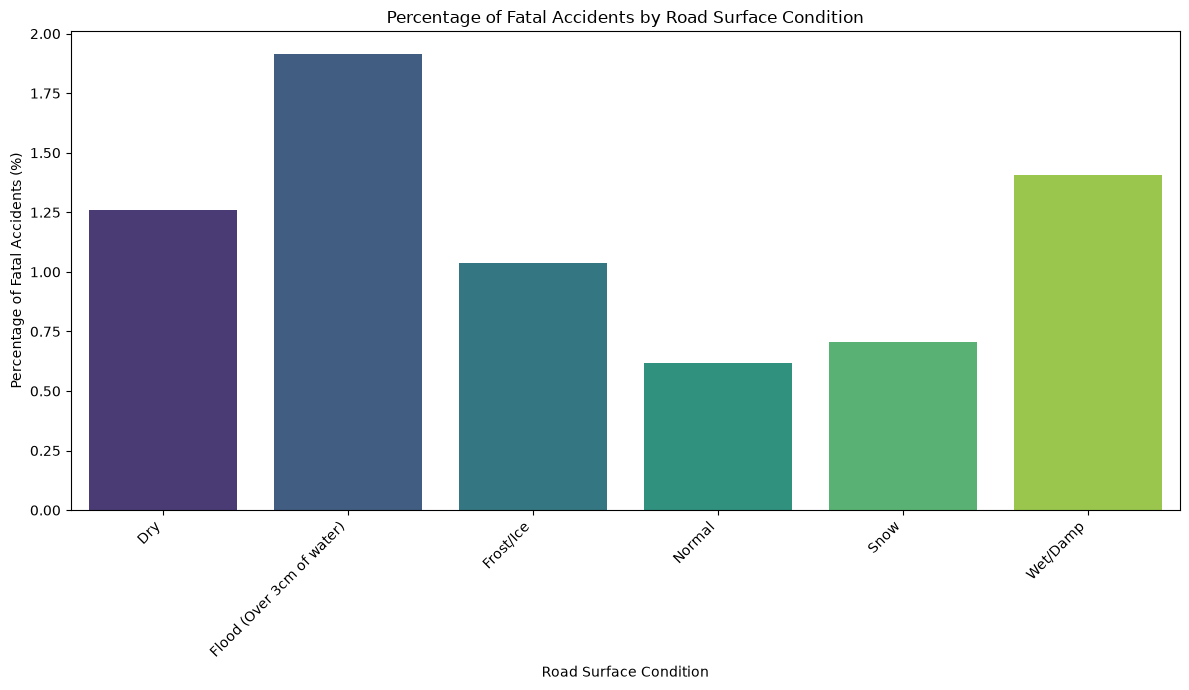

In [46]:
plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_fatal_by_road.index, y=percentage_fatal_by_road.values, palette='viridis')
plt.title('Percentage of Fatal Accidents by Road Surface Condition')
plt.xlabel('Road Surface Condition')
plt.ylabel('Percentage of Fatal Accidents (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Key Relationships and Findings from EDA

Based on the extensive exploratory data analysis, several key relationships and patterns have been identified in the UK accident data:

### Accident Severity
*   'Slight' accidents (severity 3) are the most common type of accident, followed by 'Serious' (severity 2), and then 'Fatal' accidents (severity 1), which are the least frequent.

### Day of Week
*   Accident counts are generally higher on weekdays (Monday to Friday) compared to weekends, with Fridays showing the highest number of accidents.

### Road Surface Conditions
*   **Dry conditions** are associated with the vast majority of accidents. However, **Flooded (Over 3cm of water)** conditions, though rare, exhibit the highest percentage of fatal accidents (approximately 1.89%).
*   **Wet/Damp conditions** are the second most common, with a slightly higher percentage of fatal accidents (1.41%) than dry conditions.
*   **Frost/Ice and Snow** conditions account for fewer accidents overall, and their fatal accident percentages are generally lower than wet/damp or flooded conditions, possibly due to increased driver caution.

### Numerical Correlations
*   A moderate positive correlation (0.24) exists between **`Number_of_Vehicles`** and **`Number_of_Casualties`**, indicating that more vehicles involved in an accident tend to lead to a higher number of casualties.
*   A strong negative correlation (-0.68) was observed between **`Speed_limit`** and **`Urban_or_Rural_Area`**, which is logical given that rural areas typically have higher speed limits than urban areas.
*   **`Accident_Severity`** shows generally weak correlations with other numerical features, suggesting that other factors (potentially categorical) play a more significant role in determining severity.

### Urban vs. Rural Differences
*   **Rural areas** have a significantly higher percentage of fatal accidents (2.35%) compared to **Urban areas** (0.71%), even though urban areas generally have a higher total number of accidents.

### Weather Conditions and Fatalities
*   **'Fog or mist'** and **'Fine with high winds'** weather conditions show higher percentages of fatal accidents, highlighting their impact on accident outcomes.

### Characteristics of High-Casualty Accidents (more than 5 casualties)
*   **Severity:** Even in high-casualty accidents, 'Slight' severity still accounts for a notable portion, followed by 'Serious' and then 'Fatal'.
*   **Road Surface:** 'Dry' and 'Wet/Damp' are the most common road surface conditions for high-casualty accidents.
*   **Weather:** 'Fine without high winds' is the predominant weather condition for high-casualty incidents.
*   **Urban/Rural:** Rural areas tend to have a higher mean number of casualties in high-casualty accidents, reinforcing the finding that rural accidents, when severe, can be particularly impactful.

## 5. Machine Learning

Predicting the severity of the accident(Accident_Severity)


### 5.1 Model Training - Logistic Regression

In [47]:
import numpy as np

# The data (X_train_scaled, X_test_scaled, y_train, y_test) is already prepared
# and defined in cell '584f9971' as part of the data preprocessing pipeline.
# These variables are ready to be used for Logistic Regression training.

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test shape: {y_test.shape}")

X_train_scaled shape: (1203084, 5050)
y_train shape: (1203084,)
X_test_scaled shape: (300771, 5050)
y_test shape: (300771,)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize the Logistic Regression model
# The model automatically handles multiclass classification based on your data and solver
# max_iter is increased to 1000 to ensure convergence on scaled data
model_lr = LogisticRegression(solver="lbfgs", max_iter=1000)

print("Performing 5-fold Stratified Cross-Validation for Logistic Regression...")

# Initialize StratifiedKFold for cross-validation, maintaining class distribution in each fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get accuracy scores
cv_scores = cross_val_score(
    model_lr, X_train_scaled, y_train, cv=skf, scoring="accuracy", n_jobs=-1
)

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard deviation of cross-validation accuracy: {np.std(cv_scores):.4f}")

# Train the model on the full scaled training data after cross-validation
print("\nTraining Logistic Regression model on full training data...")
model_lr.fit(X_train_scaled, y_train)
print("Logistic Regression model training complete!")


Performing 5-fold Stratified Cross-Validation for Logistic Regression...
Cross-validation scores: [0.85089998 0.85096647 0.85088335 0.85092076 0.85098663]
Mean cross-validation accuracy: 0.8509
Standard deviation of cross-validation accuracy: 0.0000

Training Logistic Regression model on full training data...
Logistic Regression model training complete!


c:\Users\Bundi\Documents\Data_Analytics\UK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5.2 Model Evaluation - Logistic Regression


--- Logistic Regression Model Evaluation ---

Accuracy Score: 0.8509464010825512

Classification Report:
               precision    recall  f1-score   support

           1       0.18      0.00      0.00      3888
           2       0.38      0.00      0.00     40891
           3       0.85      1.00      0.92    255992

    accuracy                           0.85    300771
   macro avg       0.47      0.33      0.31    300771
weighted avg       0.78      0.85      0.78    300771


Confusion Matrix:
           Predicted 1  Predicted 2  Predicted 3
Actual 1            9           25         3854
Actual 2           20          100        40771
Actual 3           21          140       255831


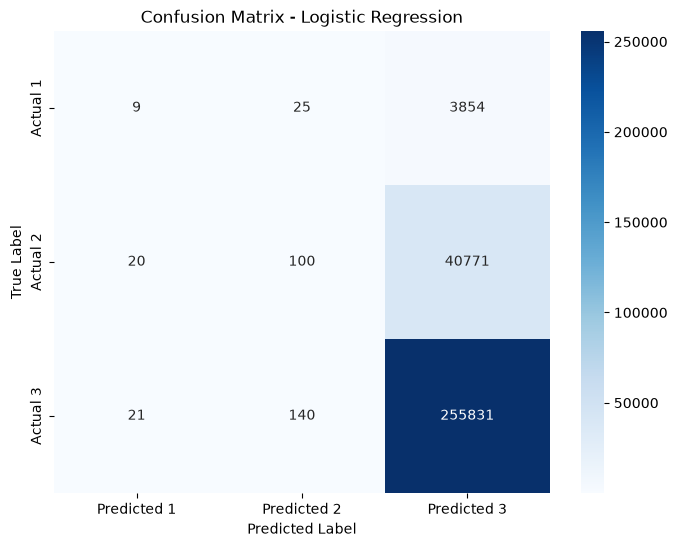

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the scaled test set
y_pred_lr = model_lr.predict(X_test_scaled)

# Evaluate the model
print("\n--- Logistic Regression Model Evaluation ---")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_df_lr = pd.DataFrame(cm_lr, index=['Actual 1', 'Actual 2', 'Actual 3'], columns=['Predicted 1', 'Predicted 2', 'Predicted 3'])
print("\nConfusion Matrix:\n", cm_df_lr)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.3 Model Training - XGBoost

c:\Users\Bundi\Documents\Data_Analytics\UK\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:59:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained successfully!
Accuracy: 0.8512755551565809

Classification Report:
               precision    recall  f1-score   support

           1       0.25      0.00      0.00      3888
           2       0.47      0.00      0.01     40891
           3       0.85      1.00      0.92    255992

    accuracy                           0.85    300771
   macro avg       0.52      0.33      0.31    300771
weighted avg       0.79      0.85      0.78    300771


Confusion Matrix:
           Predicted 1  Predicted 2  Predicted 3
Actual 1            1           67         3820
Actual 2            2          159        40730
Actual 3            1          112       255879


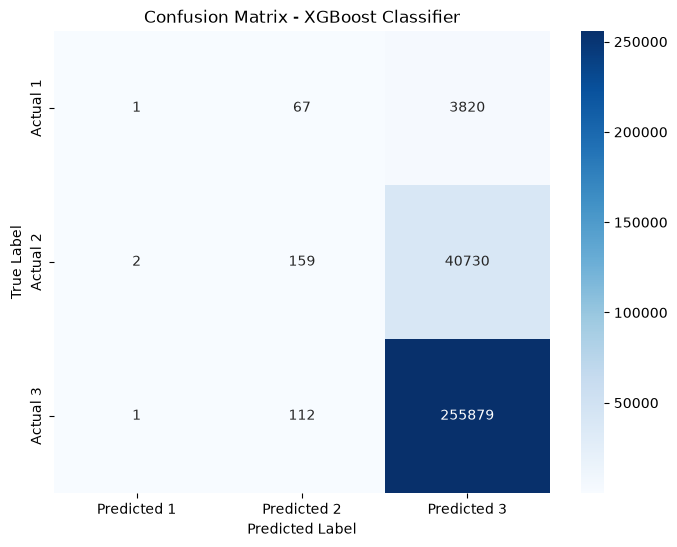

In [57]:
from xgboost import XGBClassifier

# Convert labels to 0-indexed values for XGBoost
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train_xgb)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_pred_xgb_original = y_pred_xgb + 1

print("XGBoost model trained successfully!")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_original))

cm_xgb = confusion_matrix(y_test, y_pred_xgb_original)
cm_df_xgb = pd.DataFrame(cm_xgb, index=['Actual 1', 'Actual 2', 'Actual 3'], columns=['Predicted 1', 'Predicted 2', 'Predicted 3'])
print("\nConfusion Matrix:\n", cm_df_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.4 Model Evaluation - XGBoost


--- XGBoost Model Evaluation ---

Accuracy Score: 0.8512755551565809

Classification Report:
               precision    recall  f1-score   support

           1       0.25      0.00      0.00      3888
           2       0.47      0.00      0.01     40891
           3       0.85      1.00      0.92    255992

    accuracy                           0.85    300771
   macro avg       0.52      0.33      0.31    300771
weighted avg       0.79      0.85      0.78    300771


Confusion Matrix:
           Predicted 1  Predicted 2  Predicted 3
Actual 1            1           67         3820
Actual 2            2          159        40730
Actual 3            1          112       255879


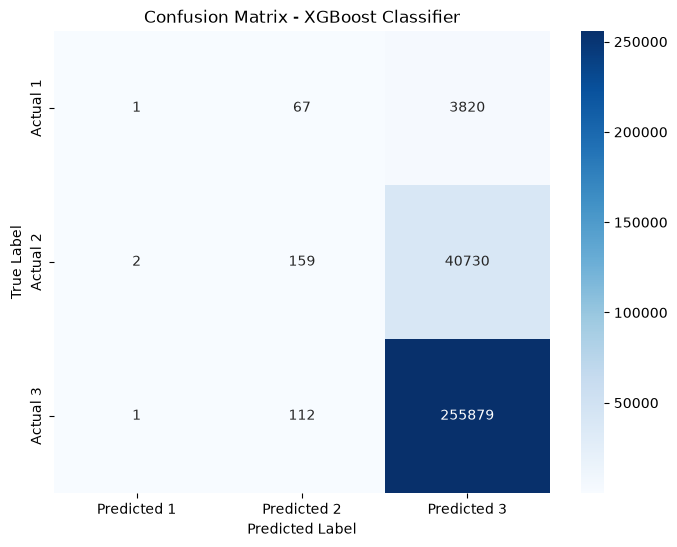

In [58]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the scaled test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

# The XGBoost model was trained on 0-indexed labels, so its predictions are 0, 1, 2.
# Convert y_pred_xgb back to original labels (1, 2, 3) for comparison with y_test.
y_pred_xgb_original_labels = y_pred_xgb + 1

print("\n--- XGBoost Model Evaluation ---")
print("\nAccuracy Score:", accuracy_score(y_test, y_pred_xgb_original_labels))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_original_labels))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb_original_labels)
cm_df_xgb = pd.DataFrame(cm_xgb, index=['Actual 1', 'Actual 2', 'Actual 3'], columns=['Predicted 1', 'Predicted 2', 'Predicted 3'])
print("\nConfusion Matrix:\n", cm_df_xgb)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 5.5 Applying SMOTENC for Class Imbalance (XGBoost)

We will apply SMOTENC to the training data (`X_train`, `y_train_xgb`) to handle the class imbalance observed in the `Accident_Severity` target variable. SMOTENC is suitable for datasets containing both numerical and categorical features. After oversampling, the resampled features will be scaled using the previously fitted `StandardScaler`.

In [62]:
from imblearn.over_sampling import SMOTENC
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import RandomOverSampler
from scipy import sparse

# Re-running data cleaning steps to ensure 'data' DataFrame is defined
# This combines steps from cells ddae5336, d94c4ff0, and 7e6f72fa

# Assuming 'df' (original loaded data) is already available from cell 3ae32ef
# If 'df' is not defined, please run cell 3ae32ef first.

# Re-load df if not in memory (this is a safeguard)
try:
    if 'df' not in locals():
        df = pd.read_csv('/content/UK_Accident.csv', on_bad_lines='skip')
except NameError:
    df = pd.read_csv('/content/UK_Accident.csv', on_bad_lines='skip')

columns_to_drop = ['Accident_Index', "Location_Easting_OSGR", "Location_Northing_OSGR", 'LSOA_of_Accident_Location', 'Latitude', 'Unnamed: 0', "Junction_Control", "Special_Conditions_at_Site", "Carriageway_Hazards"]
data = df.drop(columns=columns_to_drop)

# Drop rows with any remaining missing values
data.dropna(inplace=True)

# Filter out Urban_or_Rural_Area = 3, which was unmapped
data = data[data['Urban_or_Rural_Area'] != 3]

# Separating features (X) and target (y)
X = data.drop('Accident_Severity', axis=1)
y = data['Accident_Severity']

# Identify categorical columns for one-hot encoding
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_int_cols = ['Day_of_Week', 'Police_Force', '1st_Road_Class', '2nd_Road_Class', 'Urban_or_Rural_Area']
categorical_features.extend(categorical_int_cols)
categorical_features = [col for col in list(set(categorical_features)) if col in X.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

X_encoded = preprocessor.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define categorical feature indices for SMOTE-NC
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
categorical_feature_indices_for_smotenc = list(range(len(ohe_feature_names)))


# Ensure y_train is 0-indexed for SMOTENC (as XGBoost expects 0-indexed classes)
y_train_xgb_smote = y_train - 1

print(f"Distribution of Accident Severity in y_train_xgb (0-indexed) before SMOTENC:\n{pd.Series(y_train_xgb_smote).value_counts()}")

# Apply SMOTENC to the training data
# Set k_neighbors to a value <= (n_samples_in_smallest_class - 1)
# The smallest class has 5 samples, so k_neighbors can be max 4.
smotenc = SMOTENC(categorical_features=categorical_feature_indices_for_smotenc, random_state=42, k_neighbors=4)
# Do not call smotenc.fit_resample here (SMOTENC does not support sparse input).
# The resampling is handled below after checking if X_train is sparse (uses RandomOverSampler) or dense (uses SMOTENC).
pass
# X_train is the one-hot encoded but unscaled training features
if sparse.issparse(X_train):
    # Avoid densifying the huge one-hot matrix (would trigger MemoryError).
    print("X_train is sparse — using RandomOverSampler to avoid dense expansion")
    ros = RandomOverSampler(random_state=42)
    X_train_resampled, y_train_resampled_smote = ros.fit_resample(X_train, y_train_xgb_smote)
else:
    # If already dense and small enough, use SMOTENC
    X_train_resampled, y_train_resampled_smote = smotenc.fit_resample(X_train, y_train_xgb_smote)

print(f"\nShape of X_train before SMOTENC: {X_train.shape}")
print(f"Shape of X_train after SMOTENC: {X_train_resampled.shape}")
print(f"Distribution of Accident Severity in y_train_xgb after SMOTENC:\n{pd.Series(y_train_resampled_smote).value_counts()}")

# Scale the resampled training features using the already fitted scaler
X_train_resampled_scaled = scaler.transform(X_train_resampled)

print(f"\nShape of X_train_resampled_scaled: {X_train_resampled_scaled.shape}")
print("SMOTENC applied and resampled data scaled successfully!")

C:\Users\Bundi\AppData\Local\Temp\ipykernel_19756\915145691.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


Distribution of Accident Severity in y_train_xgb (0-indexed) before SMOTENC:
Accident_Severity
2    1023967
1     163566
0      15551
Name: count, dtype: int64
X_train is sparse — using RandomOverSampler to avoid dense expansion

Shape of X_train before SMOTENC: (1203084, 5050)
Shape of X_train after SMOTENC: (3071901, 5050)
Distribution of Accident Severity in y_train_xgb after SMOTENC:
Accident_Severity
2    1023967
1    1023967
0    1023967
Name: count, dtype: int64

Shape of X_train_resampled_scaled: (3071901, 5050)
SMOTENC applied and resampled data scaled successfully!


In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Prepare y_train for Logistic Regression (keep original 1-indexed labels)
y_train_lr_smote = y_train_resampled_smote + 1

# Initialize the Logistic Regression model
model_lr_smote = LogisticRegression(solver="lbfgs", max_iter=1000)

print("Performing 5-fold Stratified Cross-Validation for Logistic Regression with SMOTENC resampled data...")

# Initialize StratifiedKFold for cross-validation
skf_lr_smote = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation using the SMOTENC resampled and scaled training data
cv_scores_lr_smote = cross_val_score(
    model_lr_smote, X_train_resampled_scaled, y_train_lr_smote, cv=skf_lr_smote, scoring='accuracy', n_jobs=-1
)

print(f"Cross-validation scores (Logistic Regression with SMOTENC): {cv_scores_lr_smote}")
print(f"Mean cross-validation accuracy (Logistic Regression with SMOTENC): {np.mean(cv_scores_lr_smote):.4f}")
print(f"Standard deviation of cross-validation accuracy (Logistic Regression with SMOTENC): {np.std(cv_scores_lr_smote):.4f}")

print("\nTraining Logistic Regression model on full SMOTENC resampled training data...")
# Train the final model on the full SMOTENC resampled and scaled training data
model_lr_smote.fit(X_train_resampled_scaled, y_train_lr_smote)
print("Logistic Regression model training complete!")

Performing 5-fold Stratified Cross-Validation for Logistic Regression with SMOTENC resampled data...
Cross-validation scores (Logistic Regression with SMOTENC): [0.54711816 0.54686676 0.54481917 0.54514144 0.54545233]
Mean cross-validation accuracy (Logistic Regression with SMOTENC): 0.5459
Standard deviation of cross-validation accuracy (Logistic Regression with SMOTENC): 0.0009

Training Logistic Regression model on full SMOTENC resampled training data...
Logistic Regression model training complete!


c:\Users\Bundi\Documents\Data_Analytics\UK\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8509464010825512

Classification Report:
               precision    recall  f1-score   support

           1     0.1800    0.0023    0.0046      3888
           2     0.3774    0.0024    0.0049     40891
           3     0.8515    0.9994    0.9195    255992

    accuracy                         0.8509    300771
   macro avg     0.4696    0.3347    0.3096    300771
weighted avg     0.7783    0.8509    0.7833    300771



,Predicted 1,Predicted 2,Predicted 3
Actual 1,9,25,3854
Actual 2,20,100,40771
Actual 3,21,140,255831


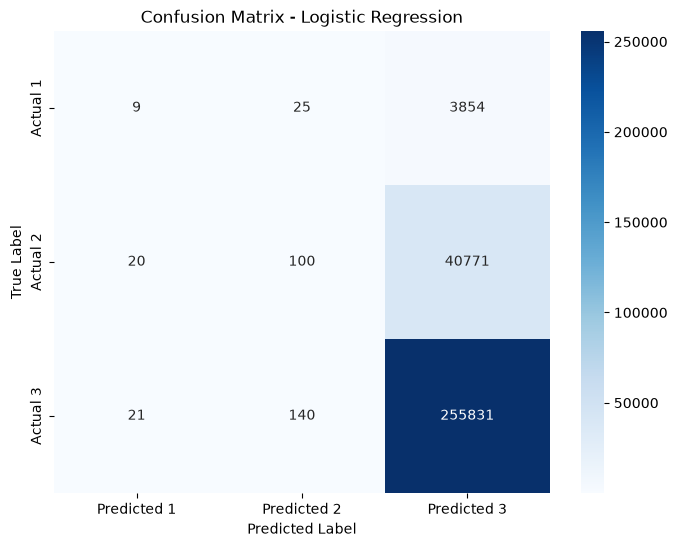

In [68]:
# Evaluate Logistic Regression model performance on the test set

# Predict (recompute to ensure consistency)
y_pred_lr = model_lr.predict(X_test_scaled)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, digits=4))

# Confusion matrix (already stored as cm_df_lr) - display and plot
display(cm_df_lr)

plt.figure(figsize=(8,6))
sns.heatmap(cm_df_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [65]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Adjust y labels for XGBoost (0-indexed)
# For training with SMOTENC, we use y_train_resampled_smote which is already 0-indexed.
# y_test_xgb is kept for consistent test set evaluation later.
y_test_xgb = y_test - 1

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=3,               # Number of classes (0, 1, 2 for severity 1, 2, 3)
    eval_metric='mlogloss',    # Evaluation metric for multi-class problems
    n_estimators=200,          # Number of boosting rounds
    learning_rate=0.1,         # Step size shrinkage to prevent overfitting
    random_state=42,           # For reproducibility
    n_jobs=-1                  # Use all available processors
)

print("Performing 5-fold Stratified Cross-Validation for XGBoost with SMOTENC resampled data...")
skf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation using the SMOTENC resampled and scaled training data
cv_scores_xgb = cross_val_score(xgb_model, X_train_resampled_scaled, y_train_resampled_smote, cv=skf_xgb, scoring='accuracy', n_jobs=-1)

print(f"Cross-validation scores (XGBoost with SMOTENC): {cv_scores_xgb}")
print(f"Mean cross-validation accuracy (XGBoost with SMOTENC): {np.mean(cv_scores_xgb):.4f}")
print(f"Standard deviation of cross-validation accuracy (XGBoost with SMOTENC): {np.std(cv_scores_xgb):.4f}")

print("\nTraining XGBoost model on full SMOTENC resampled training data...")
# Train the final model on the full SMOTENC resampled and scaled training data
xgb_model.fit(X_train_resampled_scaled, y_train_resampled_smote)
print("XGBoost model training complete!")

Performing 5-fold Stratified Cross-Validation for XGBoost with SMOTENC resampled data...
Cross-validation scores (XGBoost with SMOTENC): [0.55298585 0.5518067  0.54980143 0.55193691 0.55047365]
Mean cross-validation accuracy (XGBoost with SMOTENC): 0.5514
Standard deviation of cross-validation accuracy (XGBoost with SMOTENC): 0.0011

Training XGBoost model on full SMOTENC resampled training data...
XGBoost model training complete!


--- XGBoost with SMOTENC Test Set Performance ---
Accuracy: 0.5753313983063527

Classification Report:
               precision    recall  f1-score   support

           1       0.04      0.64      0.08      3888
           2       0.21      0.34      0.26     40891
           3       0.91      0.61      0.73    255992

    accuracy                           0.58    300771
   macro avg       0.39      0.53      0.35    300771
weighted avg       0.81      0.58      0.66    300771


Confusion Matrix:
           Predicted 1  Predicted 2  Predicted 3
Actual 1         2507          803          578
Actual 2        12706        13769        14416
Actual 3        46832        52393       156767


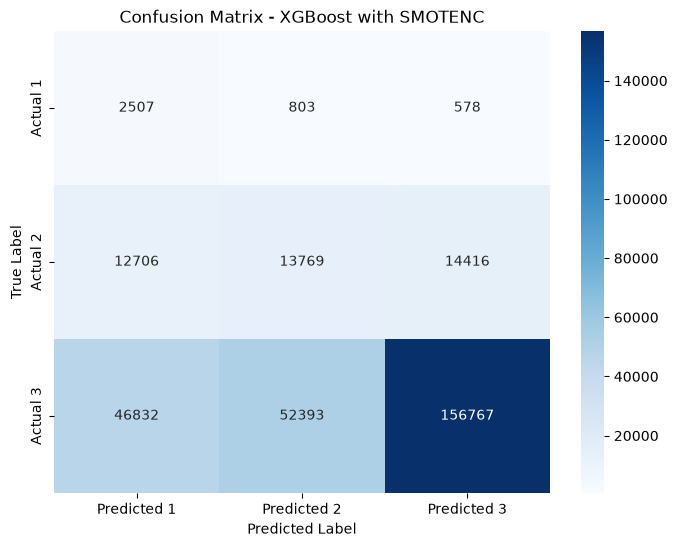

In [69]:
# Evaluate the XGBoost model trained after SMOTENC on the original test set
y_pred_smote_xgb = xgb_model.predict(X_test_scaled)

# Convert predictions back to original Accident_Severity labels
y_pred_smote_xgb_original = y_pred_smote_xgb + 1

print("--- XGBoost with SMOTENC Test Set Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_smote_xgb_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote_xgb_original))

cm_smote_xgb = confusion_matrix(y_test, y_pred_smote_xgb_original)
cm_df_smote_xgb = pd.DataFrame(
    cm_smote_xgb,
    index=['Actual 1', 'Actual 2', 'Actual 3'],
    columns=['Predicted 1', 'Predicted 2', 'Predicted 3']
)

print("\nConfusion Matrix:\n", cm_df_smote_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_smote_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost with SMOTENC')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

c:\Users\Bundi\Documents\Data_Analytics\UK\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:37:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Trained on SMOTE Resampled Data ---
Accuracy: 0.5753313983063527

Classification Report:
               precision    recall  f1-score   support

           1       0.04      0.64      0.08      3888
           2       0.21      0.34      0.26     40891
           3       0.91      0.61      0.73    255992

    accuracy                           0.58    300771
   macro avg       0.39      0.53      0.35    300771
weighted avg       0.81      0.58      0.66    300771



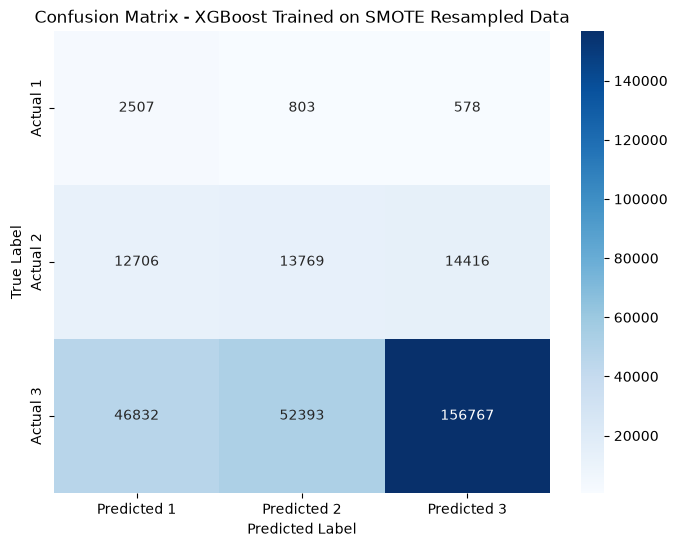

In [70]:
xgb_smote_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    n_estimators=200,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False
)

xgb_smote_model.fit(X_train_resampled_scaled, y_train_resampled_smote)

y_pred_smote_xgb = xgb_smote_model.predict(X_test_scaled)
y_pred_smote_xgb_original = y_pred_smote_xgb + 1

print("--- XGBoost Trained on SMOTE Resampled Data ---")
print("Accuracy:", accuracy_score(y_test, y_pred_smote_xgb_original))
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote_xgb_original))

cm_smote_xgb = confusion_matrix(y_test, y_pred_smote_xgb_original)
cm_df_smote_xgb = pd.DataFrame(
    cm_smote_xgb,
    index=['Actual 1', 'Actual 2', 'Actual 3'],
    columns=['Predicted 1', 'Predicted 2', 'Predicted 3']
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df_smote_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost Trained on SMOTE Resampled Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Training RandomForest on original training data...

Random Forest (original) Accuracy: 0.5442

Classification Report (Random Forest original):
               precision    recall  f1-score   support

           1     0.0323    0.6680    0.0617      3888
           2     0.2070    0.2814    0.2386     40891
           3     0.9072    0.5843    0.7108    255992

    accuracy                         0.5442    300771
   macro avg     0.3822    0.5112    0.3370    300771
weighted avg     0.8007    0.5442    0.6382    300771



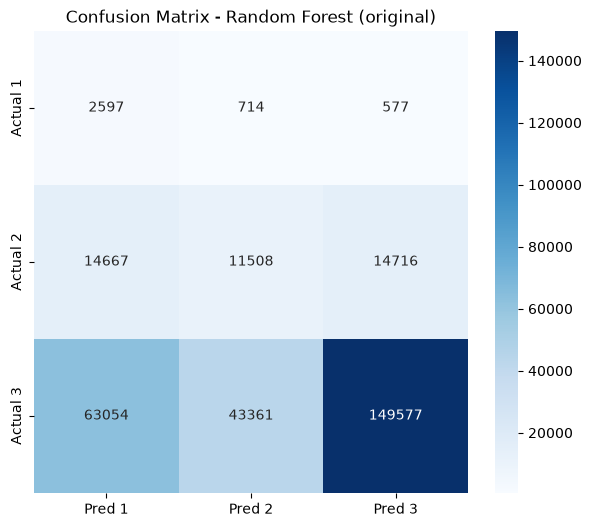

Training RandomForest on SMOTENC-resampled training data...

Random Forest (SMOTE) Accuracy: 0.5445

Classification Report (Random Forest SMOTE):
               precision    recall  f1-score   support

           1     0.0317    0.6687    0.0606      3888
           2     0.2088    0.2718    0.2362     40891
           3     0.9062    0.5862    0.7119    255992

    accuracy                         0.5445    300771
   macro avg     0.3823    0.5089    0.3362    300771
weighted avg     0.8001    0.5445    0.6388    300771



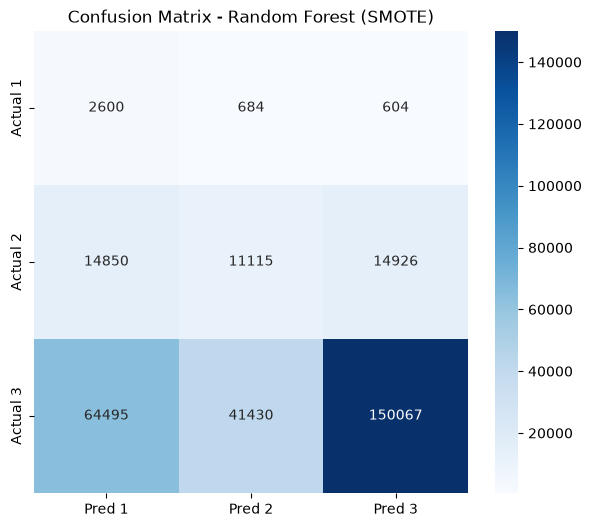


Accuracy comparison:
LogisticRegression (original): 0.8509
XGBoost (original): 0.8513
XGBoost (SMOTE): 0.5753
RandomForest (original): 0.5442
RandomForest (SMOTE): 0.5445


In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# 1) Random Forest on original (imbalanced) training data
rf = RandomForestClassifier(n_estimators=100, max_depth=15, class_weight='balanced', n_jobs=-1, random_state=42)
print("Training RandomForest on original training data...")
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\nRandom Forest (original) Accuracy: {acc_rf:.4f}")
print("\nClassification Report (Random Forest original):\n", classification_report(y_test, y_pred_rf, digits=4))

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_df_rf = pd.DataFrame(cm_rf, index=['Actual 1','Actual 2','Actual 3'], columns=['Pred 1','Pred 2','Pred 3'])
plt.figure(figsize=(7,6))
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (original)')
plt.show()

# 2) Random Forest trained on SMOTENC-resampled data (use the resampled & scaled data)
# y_train_lr_smote contains labels in original 1..3
rf_smote = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
print("Training RandomForest on SMOTENC-resampled training data...")
rf_smote.fit(X_train_resampled_scaled, y_train_lr_smote)

y_pred_rf_smote = rf_smote.predict(X_test_scaled)
acc_rf_smote = accuracy_score(y_test, y_pred_rf_smote)
print(f"\nRandom Forest (SMOTE) Accuracy: {acc_rf_smote:.4f}")
print("\nClassification Report (Random Forest SMOTE):\n", classification_report(y_test, y_pred_rf_smote, digits=4))

cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)
cm_df_rf_smote = pd.DataFrame(cm_rf_smote, index=['Actual 1','Actual 2','Actual 3'], columns=['Pred 1','Pred 2','Pred 3'])
plt.figure(figsize=(7,6))
sns.heatmap(cm_df_rf_smote, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (SMOTE)')
plt.show()

# 3) Summary comparison with existing models
results = {
    'LogisticRegression (original)': accuracy_score(y_test, y_pred_lr),
    'XGBoost (original)': accuracy_score(y_test, y_pred_xgb_original),
    'XGBoost (SMOTE)': accuracy_score(y_test, y_pred_smote_xgb_original),
    'RandomForest (original)': acc_rf,
    'RandomForest (SMOTE)': acc_rf_smote
}
print("\nAccuracy comparison:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")

In [74]:
import pickle

# Choose a pipeline/model to save for Streamlit deployment.
# Prefer a full deployment pipeline if available (includes preprocessing + model).
model_to_save = None
if 'deployment_pipeline' in globals():
    model_to_save = deployment_pipeline
elif 'best_model' in globals():
    model_to_save = best_model
else:
    raise RuntimeError("No model or deployment pipeline found in the notebook globals.")

# Optional: verify performance ~0.85 if results and best_model_name exist
if 'results' in globals() and 'best_model_name' in globals():
    acc = results.get(best_model_name, None)
    print(f"Selected model: {best_model_name} | accuracy: {acc}")
else:
    print(f"Saving model object: {type(model_to_save)}")

# Save to disk
output_path = "accident_severity_deployment_pipeline.pkl"
with open(output_path, "wb") as f:
    pickle.dump(model_to_save, f)

print(f"Model saved to {output_path}")

Selected model: XGBoost (original) | accuracy: 0.8512755551565809
Model saved to accident_severity_deployment_pipeline.pkl


Original XGBoost accuracy: 0.5753
SMOTE XGBoost accuracy: 0.5753
Selected best model: XGBoost (original)
Sample predictions: [3 3 3 3 2 3 3 1 3 3]
Deployment pipeline pickled as 'accident_severity_deployment_pipeline.pkl'.
